<a href="https://colab.research.google.com/github/pinkadace-code/fita-ml-course/blob/main/week3/week3_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

url = 'https://raw.githubusercontent.com/pinkadace-code/fita-ml-course/main/week1/shoppers_clean.csv'
df = pd.read_csv(url)
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)


Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))


Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                     -0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00         0.00       0.00       -0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

Normalizācija ir svarīga klasterizācijai, jo K-Means grupē punktus pēc attāluma. Tas nozīmē, ka bez normalizācijas iezīmes ar lielākiem skaitļiem automātiski "dominēs" pār iezīmēm ar maziem skaitļiem — pat ja tās saturiski nav svarīgākas.

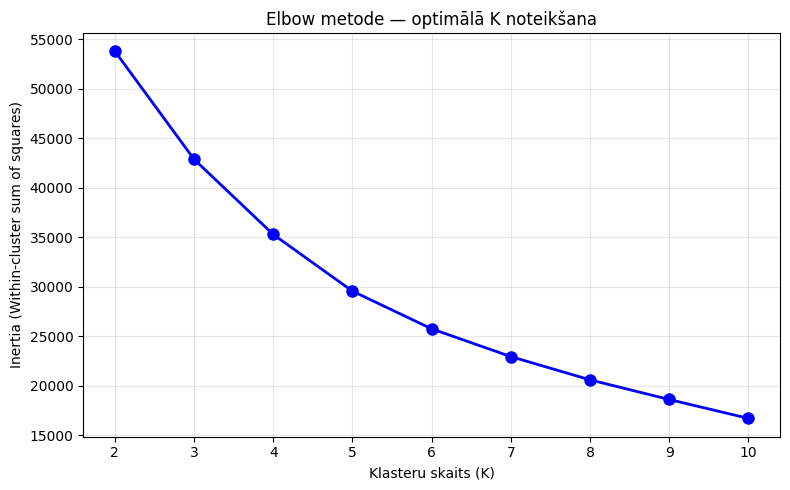

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
for k, inertia in zip(K_range, inertias):
    print(f"k={k}: {inertia:.0f}")

k=2: 53804
k=3: 42889
k=4: 35292
k=5: 29565
k=6: 25757
k=7: 22950
k=8: 20602
k=9: 18615
k=10: 16708


K_range nozīmē, ka tiek izvēlēts klasteru skaits testēšanai no 2 līdz 10. Sākam ar 2 klasteriem, jo nav jēgas sadalīt klientus tikai vienā klasterī, savukārt beidzam ar 10, jo lielāks klasteru skaits kļūst
grūti interpretējams.

Es izvēlos K vērtību 4, jo - lai gan grafikā nav skaidri izteikts "elkonis", analizējot inertia krituma tempu starp k vērtībām skaitliski, vērojams, ka vislielākie kritumi notiek no k=2 uz k=3 (-10915) un no k=3 uz k=4 (-7597). Sākot ar k=5, kritums kļūst vienmērīgāks un lēnāks, kas liecina, ka papildu klasteri vairs nedod ievērojamu ieguvumu.

Klasteru skaita izvēlē nav vienas "pareizas" atbildes. K izvēle ir
interpretācija, kurā apvieno matemātisko analīzi ar biznesa loģiku.
Šajā gadījumā k=4 ir saprātīgs kompromiss — pietiekami daudz segmentu,
lai raksturotu dažādus klientu uzvedības tipus, bet ne pārāk daudz,
lai tos grūti pārvaldītu mārketinga kontekstā.

In [6]:
K = 4  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())


Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


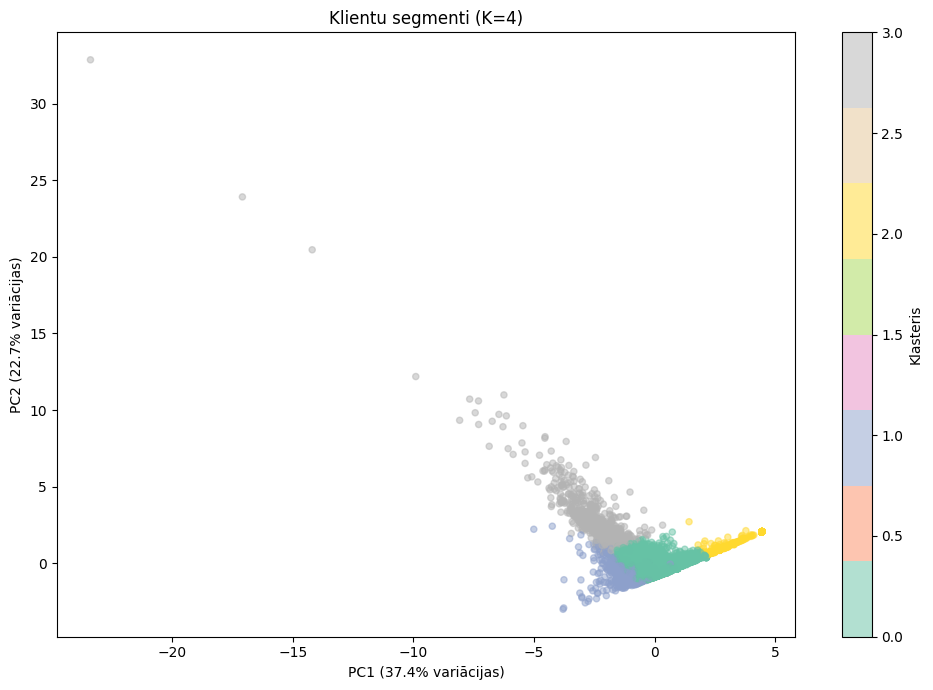

In [7]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()


In [8]:
print(f"PC1 izskaidro: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 izskaidro: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Kopā: {sum(pca.explained_variance_ratio_):.1%}")

PC1 izskaidro: 37.4%
PC2 izskaidro: 22.7%
Kopā: 60.1%


Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


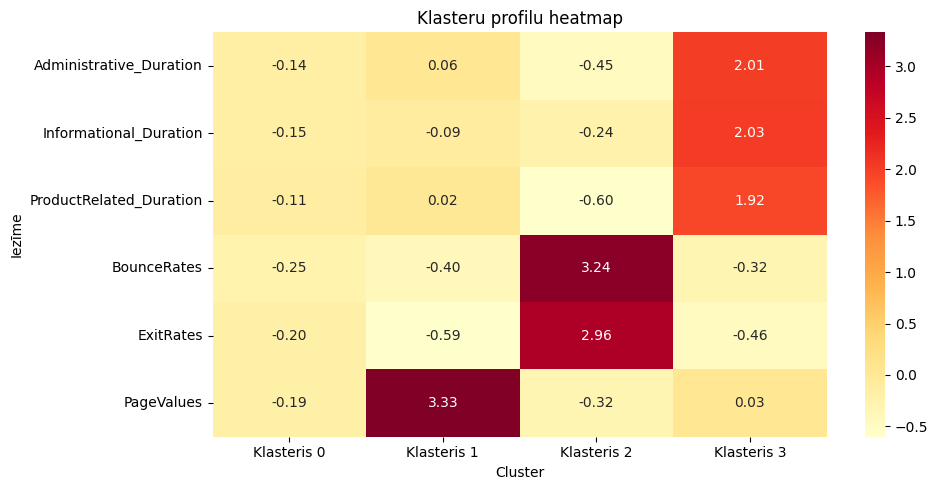

In [9]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()


Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


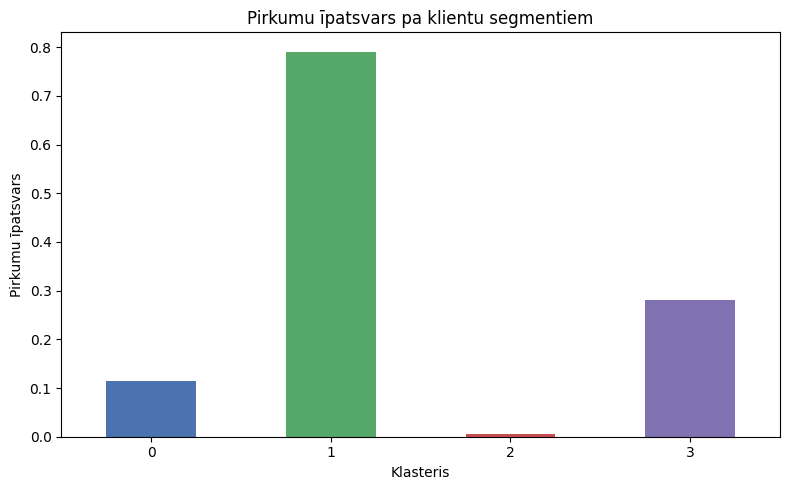

In [10]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Pircēji tika sadalīti 4 klasteros:

Klasteris 0 (9872 klienti — 80%) - "pasīvie apmeklētāji".
Visi rādītāji nedaudz zem vidējā, šie klienti apmeklē veikalu, bet nedara neko īpašu. Tā kā šī ir lielākā grupa, pat mazs uzlabojums dotu lielu efektu. Jānosūta personalizēts e-pasts ar populārākajām precēm tajā kategorijā, kuras lapas klients apmeklēja.

Klasteris 1 (656 klienti) - "augstvērtīgie pircēji". Ļoti augsts PageValues = 3.33, savukārt BounceRates un ExitRates zemi. Šie klienti aktīvi virzās uz pirkumu un visticamāk nopērk. Tā kā šie klienti jau pērk preces, mērķis būtu palielināt vidējo pirkuma vērtību - kad prece tiktu pievienota grozam, jāpiedāvā iegādāties arī citas, saistītas preces.

Klasteris 2 (931 klients) - "problēmklienti". Ļoti augsti BounceRates = 3.24, ExitRates = 2.96. PageValues gandrīz 0. Šie klienti ierodas un uzreiz aiziet. Mērķis būtu viņus aizturēt, pirms lapas aizvēršanas piedāvājot atlaidi pirmajam pirkumam.

Klasteris 3 (871 klients) - "aktīvie pārlūkotāji". Administrative un Informational Duration = ~2.0, ProductRelated arī augsts. Daudz laika pavada lapās, bet PageValues zems - preci nopērk reti. Mērķis būtu pārliecināt par pirkumu - pēc preces apskates, bet neizdarīta pirkuma klientam nākamajās dienās rādīt reklāmas ar šo preci.

In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus (tu tos jau ielādēji, tāpēc varētu būt kļūda)
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)  # Izņem mūsu klasteru kolonu

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")


Datu kopa: 12330 rindas, 27 features


In [12]:
print(X.columns.tolist())

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'Engagement_Score']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Viena split F1 score: {single_f1:.3f}")


Viena split F1 score: 0.625


In [14]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")


5-fold CV F1 scores: [0.667 0.664 0.643 0.556 0.61 ]
Vidējais F1: 0.628
Standarta novirze: 0.041


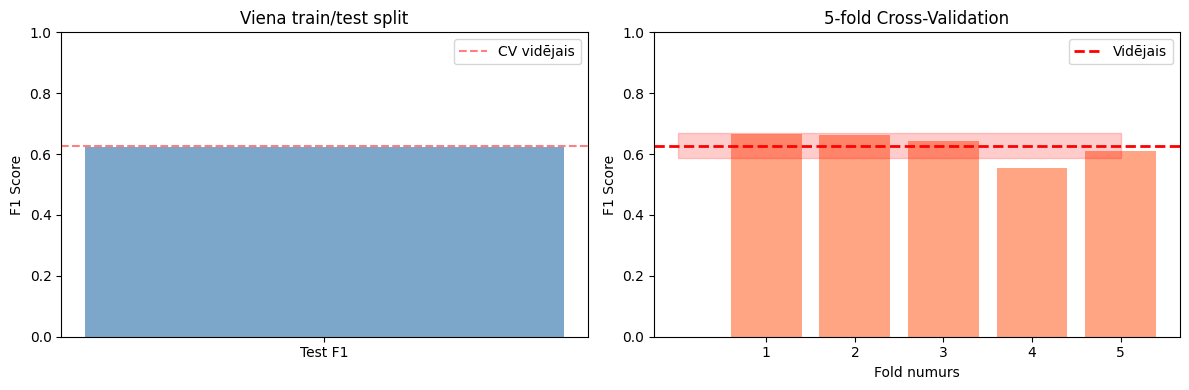

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()


Vienas split F1 un CV vidējais F1 ir gandrīz identiski, kas nozīmē, ka izvēlētais split diezgan labi atainoja modeļa spēju prognozēt. Tomēr CV vidējais F1 rezultāts ir uzticamāks, jo nav tik daudz atkarīgs no tā, kuri klienti nejauši nonāk testa kopā.

Standarta novirze parāda to, cik stabils ir izvēlētais modelis. Jo mazāka ir standarta novirze, jo modelis ir labāks.

Ir iespējams, ka “pārmēģinot” tiktu iegūts pavisam cits vienas split F1, jo tas ir atkarīgs no tā, kuri klienti nonāk test kopā nejauši izvēlētā dalījuma ceļā.


In [16]:
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"F1 ar data leakage: {f1_leaked:.3f}")


F1 ar data leakage: 0.625


In [17]:
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI - Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")


F1 ar Pipeline: 0.627 ± 0.042


In [18]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))


                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.624809 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.627463     DROŠS! Objektīvs


Data leakage notiek, kad modelis apmācības procesā iegūst informāciju,
kurai nevajadzētu būt pieejamai, šajā gadījumā — informāciju no test datiem. Rezultātā modelis izskatās labāks nekā patiesībā ir, jo tas ir "redzējis" test datus jau pirms novērtēšanas.

Ja `scaler.fit_transform(X)` tiek veikts uz VISIEM datiem pirms
`train_test_split`, tad skalers iegaumē vidējo un standartnovirzi,
kas ietver arī test datu statistiku. Tas nozīmē, ka test datu informācija
ir "noplūdusi" apmācības procesā — modelis netieši zina kaut ko par
datiem, uz kuriem tas vēlāk tiks novērtēts.

Pipeline savieno visus apstrādes soļus vienā objektā. Kad cross-validation to izmanto, katrā kārtā StandardScaler tiek piemērots tikai uz train datiem, bet test dati tiek tikai transformēti — bez jebkādas ietekmes uz skalera parametriem. Tā tiek garantēts, ka test dati nav ņemti vērā līdz pat novērtēšanas brīdim.

Reālajā biznesā modelis tiek novērtēts pēc tā, cik labi tas strādā uz
jauniem, neredzētiem datiem — piemēram, nākamā mēneša klientiem.
Ja modelis ir apmācīts ar data leakage, tā novērtētā precizitāte ir pārāk
optimistiska un neatspoguļo reālo sniegumu. Tas var novest pie kļūdainiem biznesa lēmumiem, jo modelis ražošanā strādās sliktāk nekā testos.

In [19]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls — 2 parametri, 3×3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU kodolus
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.638


In [20]:
# Kādi bija VISIEM parametriem?
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("Top 5 parametru kombinācijas:")
print(results_table.head())


Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
5                                         200   
7                                         100   
3                                          50   
4                                         100   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.652508        0.008446  
5                                       10         0.648102        0.010952  
7                                       20         0.647897        0.012657  
3                                       10         0.642937        0.006181  
4                                       10         0.641351        0.012192  


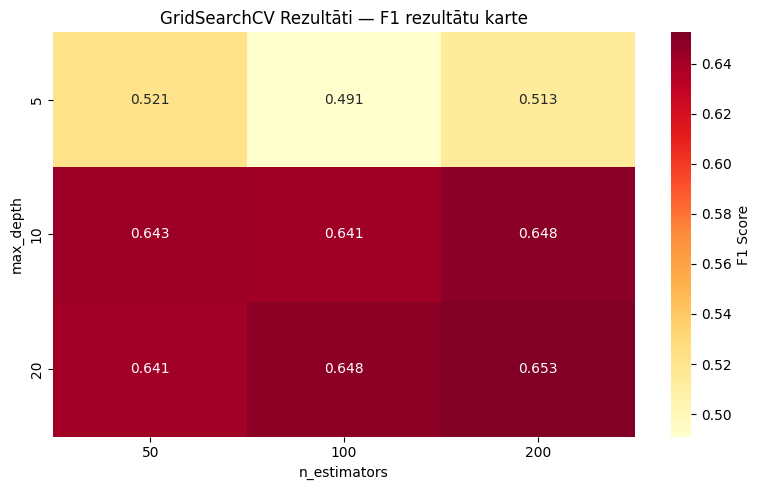

In [21]:
# Pivot tabula — n_estimators kolonnas, max_depth rindas
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()


In [22]:
print(results_table.to_string())

   param_randomforestclassifier__n_estimators  param_randomforestclassifier__max_depth  mean_test_score  std_test_score
8                                         200                                       20         0.652508        0.008446
5                                         200                                       10         0.648102        0.010952
7                                         100                                       20         0.647897        0.012657
3                                          50                                       10         0.642937        0.006181
4                                         100                                       10         0.641351        0.012192
6                                          50                                       20         0.640961        0.003039
0                                          50                                        5         0.521311        0.028739
2                                       

Labākie parametri - `n_estimators=200, max_depth=20` ar F1=0.653.
Dziļāki koki (max_depth=20) un lielāks koku skaits (200) deva
vislabāko rezultātu.

Starpība starp labāko un sliktāko ir ļoti būtiska - 0.162:
- labākais: `n_estimators=200, max_depth=20`, kur F1 = 0.653
- sliktākais: `n_estimators=100, max_depth=5`, kur F1 = 0.491

Heatmapā skaidri redzamas divas zonas:
- karstā zona (augstāki F1): `max_depth=10` un `max_depth=20` —
  neatkarīgi no koku skaita F1 ir starp 0.641 un 0.653
- aukstā zona (zemāki F1): `max_depth=5` — visas trīs kombinācijas
  ir dramatiski zemākas (0.491–0.521), ar augstu standartnovirzi, kas norāda uz nestabilu modeli.

GridSearchCV uzlaboja rezultātu - Sākotnēji manuāli tika izvēlēti `max_depth=10, n_estimators=100`, kas deva F1=0.625. GridSearchCV atrada `max_depth=20, n_estimators=200` ar F1=0.638 uz test datiem — neliels, bet reāls uzlabojums. Galvenā vērtība ir tā, ka meklēšana notika sistemātiski un automātiski, nevis ar manuālu izmēģināšanu.

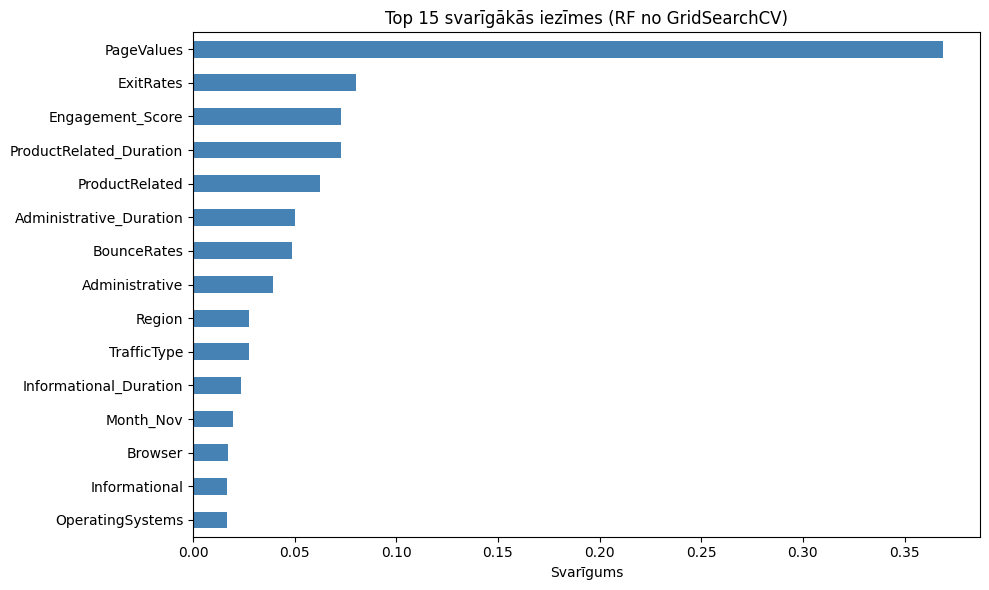

Top 10 svarīgākās iezīmes:
PageValues                 0.368686
ExitRates                  0.080372
Engagement_Score           0.073001
ProductRelated_Duration    0.072863
ProductRelated             0.062348
Administrative_Duration    0.050095
BounceRates                0.048854
Administrative             0.039555
Region                     0.027611
TrafficType                0.027602
dtype: float64


In [23]:
# Iegūt labāko trenēto modeli
best_model = grid.best_estimator_

# RandomForestClassifier nodrošina feature_importances_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

# Sakārtot un vizualizēt
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

# Arī teksts
print("Top 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))


3 svarīgākās iezīmes:
*   PageValues - augstais rezultāts apstiprina, ka lapa, kuru klients apmeklē ceļā uz pirkumu ir visspēcīgākais signāls par pirkuma izdarīšanu.
*   ExitRates - klients, kas aiziet no produkta lapas, visticamāk pirkumu neizdarīs. Augsts ExitRate konkrētā lapā nozīmē, ka tur kaut kas atbaida klientu — varbūt cena, varbūt lapas dizains, varbūt produkta apraksts. Modelis to uztver kā spēcīgu negatīvu signālu.
*   Engagement_Score - iezīme apvieno divus signālus vienā — ilgs laiks produktu lapās mīnus augsts BounceRate. Klients ar augstu engagement_Score ir ieinteresēts un veikalu nepamet — klasisks apmeklētājs, kas ir gatavs pirkt.

Kā šo informāciju izmantot mārketinga departamentam:
*  PageValues — reāllaikā identificēt klientus ar augstu PageValues un uzreiz piedāvāt viņiem bezmaksas piegādi vai nelielu atlaidi, lai pamudinātu uz pirkumu.
*  ExitRates — atrast lapas ar augstu ExitRate un uzlabot tieši tās — pievienot labākus produktu attēlus, skaidrāku cenu, klientu atsauksmes.
*  Engagement_Score — klientus ar augstu Engagement_Score, kas tomēr pirkumu neizdarīja, iekļaut retargeting kampaņā — viņi jau ir ieinteresēti, vajag tikai nelielu "grūdienu".












In [24]:
from xgboost import XGBClassifier

# RandomForest (ar labākajiem parametriem no GridSearchCV)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# XGBoost (standarta parametri, vienkāršības dēļ)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    eval_metric='logloss'
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

# Salīdzinājums
print(f"RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")


RandomForest CV F1: 0.633 ± 0.043
XGBoost CV F1:      0.623 ± 0.062


In [25]:
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
                  f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"]
})

print(comparison_table.to_string(index=False))


     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.633304 0.043479 0.568-0.688
     XGBoost        0.623107 0.061683 0.553-0.723


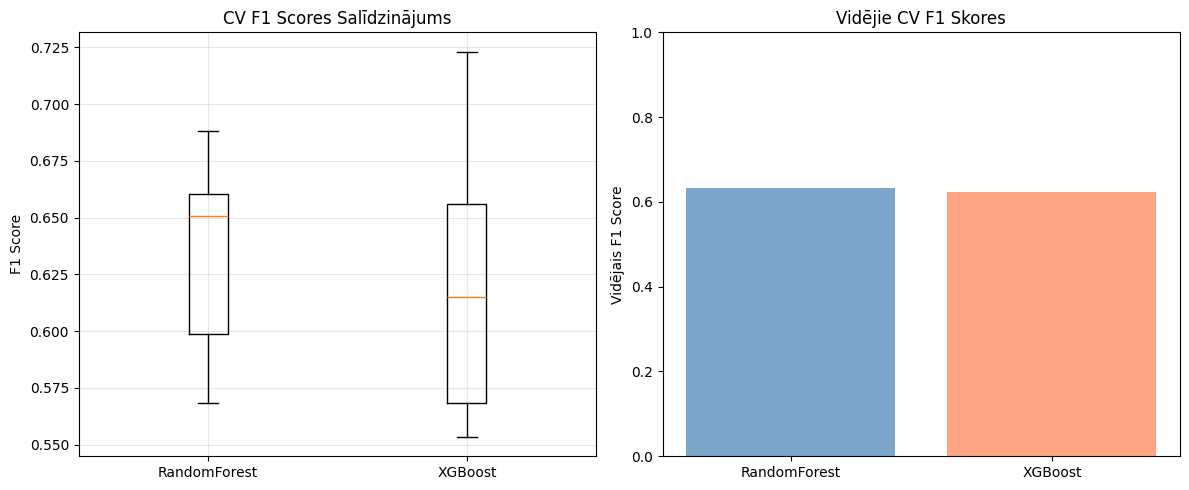

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, tick_labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

# Bar plot ar vidējiem
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], alpha=0.7, color=['steelblue', 'coral'])
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


## Modeļu salīdzinājuma kopsavilkums

### Kurš modelis ir labāks?
Atbilde nav viennozīmīga — atkarīga no tā, ko uzskatām par "labāku":
- **Vidējais F1**: RandomForest (0.633) nedaudz apsteidz XGBoost (0.623)
- **Stabilitāte**: RandomForest (std=0.043) ir ievērojami stabilāks nekā
  XGBoost (std=0.062)
- **Maksimālais potenciāls**: XGBoost (0.723) pārspēj RandomForest (0.688)

### Vai atšķirība ir statistiski nozīmīga?
Visticamāk — nē. Starpība vidējos F1 scores ir tikai **0.010**, kas ir
daudz mazāka par abu modeļu standarta novirzi. Tas nozīmē, ka atšķirība
varētu būt nejaušības rezultāts, nevis patiesa modeļu spēju atšķirība.
Lai to apstiprinātu, būtu nepieciešams formāls statistiskais tests un
lielāks CV kārtu skaits.

### Kuru modeli es izvēlētos gala projektam?
Izvēlētos **RandomForest** šādu iemeslu dēļ:
1. **Augstāks vidējais F1** — vidēji sniedz labākus rezultātus;
2. **Lielāka stabilitāte** — mazāka standartnovirze nozīmē paredzamāku uzvedību ar jauniem datiem;
3. **Optimizēti parametri** — tika apmācīts ar GridSearchCV labākajiem
   parametriem, kamēr XGBoost izmantoja standarta parametrus —
   salīdzinājums nav pilnīgi godīgs.

Tomēr, ja laiks atļautu, nākamais solis būtu **XGBoost optimizācija ar
GridSearchCV** — iespējams, tas atklātu šī modeļa patieso potenciālu
un mainītu izvēli.